In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('mushroom.csv')
df.head(10)

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245
5,389,convex,grooves,pink,no,spicy,attached,crowded,broad,orange,...,universal,white,one,sheathing,white,scattered,woods,poisonous,4.337043,16.189338
6,330,bell,smooth,brown,no,anise,free,distant,broad,buff,...,partial,white,two,flaring,green,scattered,leaves,poisonous,12.702359,24.662015
7,98,conical,fibrous,white,yes,none,notched,close,narrow,black,...,partial,brown,one,large,orange,several,woods,poisonous,11.963690,19.408506
8,597,conical,grooves,green,yes,pungent,attached,crowded,narrow,buff,...,universal,yellow,two,evanescent,chocolate,solitary,woods,edible,14.272490,13.260537
9,16,convex,scaly,brown,yes,almond,attached,crowded,broad,red,...,partial,white,none,zone,green,clustered,leaves,poisonous,11.842597,4.216489


In [3]:
df.shape

(2000, 26)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 
 14  stalk_co

In [5]:
df.describe()

,Unnamed: 0,stalk_height,cap_diameter
count,2000.000000,2000.000000,2000.000000
mean,624.974000,8.449118,12.314345
std,375.091938,3.697217,7.048845
min,0.000000,2.000000,1.000000
25%,290.000000,5.291009,5.723521
50%,607.000000,8.318596,12.124902
75%,957.250000,11.781272,18.698605
max,1279.000000,15.095066,25.000054


In [6]:
df.isnull().sum()

Unnamed: 0                  0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64

# Exploratory data analysis

In [7]:
df['class'].value_counts()

class
poisonous    1400
edible        600
Name: count, dtype: int64

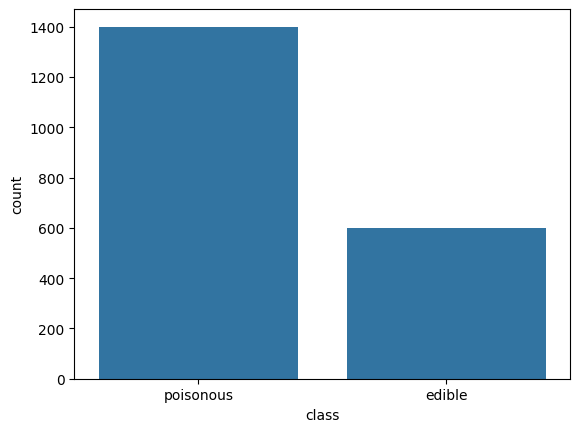

In [8]:
sns.countplot(x='class',data=df)
plt.show()

the dataset classes are heavily imbalanced. we need to take care of this imbalance classes.

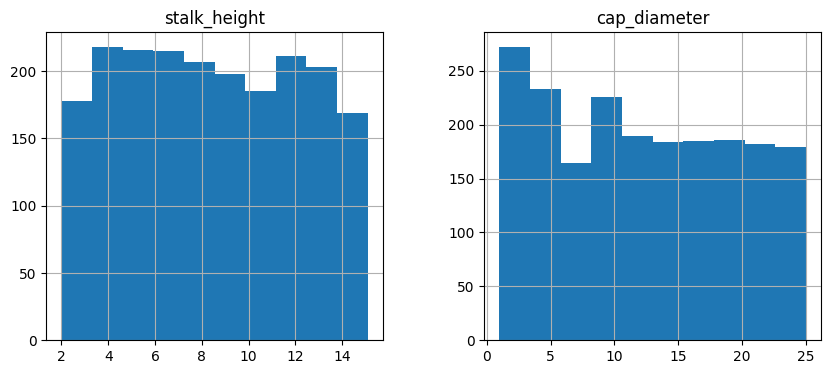

In [11]:
df[['stalk_height','cap_diameter']].hist(figsize=(10,4))
plt.show()

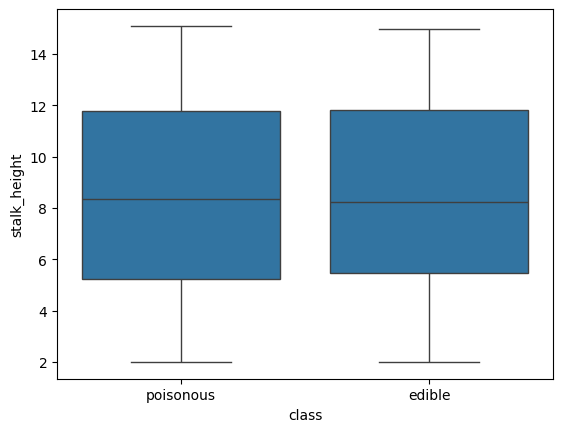

In [12]:
sns.boxplot(x='class',y='stalk_height',data=df)
plt.show()

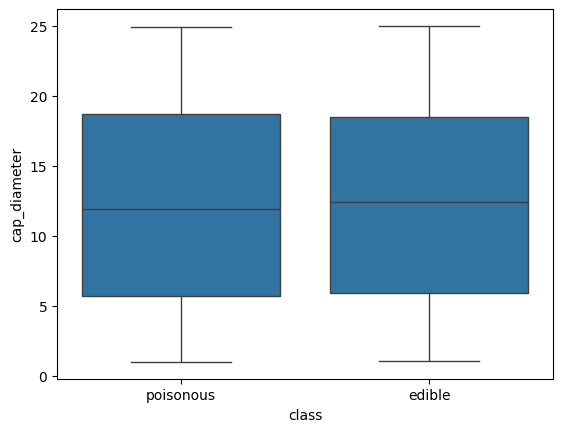

In [13]:
sns.boxplot(y='cap_diameter',x = 'class',data=df)
plt.show()

Both classes mostly lie in similar ranges for both features, the  class distribution with respect to the features tell us that these features have low predicting power for classes. probably the categorical features may help in predictions.

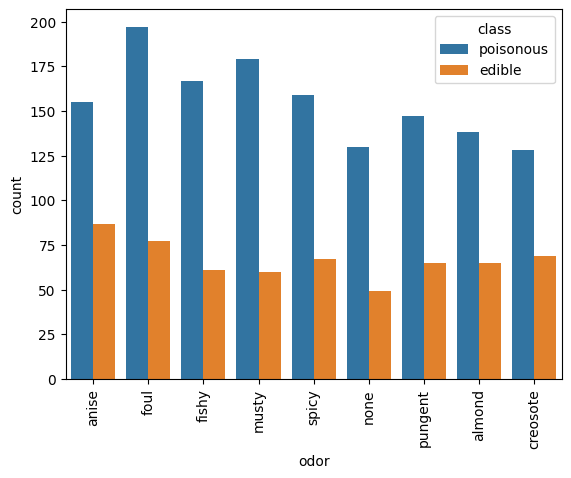

In [15]:
df['odor'].value_counts()
sns.countplot(x='odor',hue='class',data=df)
plt.xticks(rotation=90)
plt.show()

odor looks strongly related to the target variable. if a mushroom have strong smell , it is likely poisonous.

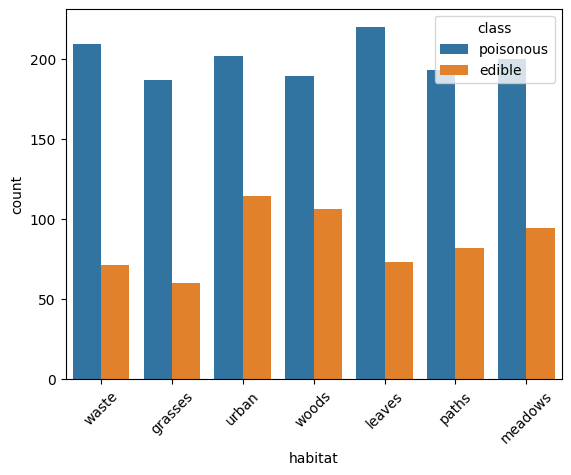

In [16]:
df['habitat'].value_counts()
sns.countplot(x='habitat', hue='class', data=df)
plt.xticks(rotation=45)
plt.show()


habitat is mostly weak to a moderate predictor for the target variable

# Preprocessing

In [20]:
df.drop(columns='Unnamed: 0',inplace=True)

In [21]:
df.head()

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [22]:
X = df.drop('class',axis=1)
y= df['class']

X.shape, y.shape

((2000, 24), (2000,))

In [23]:
One_hot_X = pd.get_dummies(X,drop_first=True)
One_hot_X.shape

(2000, 104)

SVM is good at handling data with high dimentions. KNN suffers due to its distance based metrics while SVM uses margins for classification. SVM is sensitive to feature scale so we need to scale the numerical features.

# Train test split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(One_hot_X,y,
                                                    test_size=0.2,
                                                    random_state=42,stratify=y)



In [30]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1600, 104), (400, 104), (1600,), (400,))

# scaling the features

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((1600, 104), (400, 104))

# Base model- SVM

In [32]:
from sklearn.svm import SVC

svm_model = SVC(kernel ='linear',class_weight='balanced')
svm_model.fit(X_train_scaled,y_train)

SVC(class_weight='balanced', kernel='linear')

In [33]:
y_pred_base = svm_model.predict(X_test_scaled)

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test,y_pred_base)
precision = precision_score(y_test,y_pred_base, pos_label='poisonous')
recall = recall_score(y_test, y_pred_base, pos_label='poisonous')
f1 = f1_score(y_test, y_pred_base,pos_label='poisonous')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.6
Precision: 0.7884615384615384
Recall: 0.5857142857142857
F1 Score: 0.6721311475409836


In [50]:
cm = confusion_matrix(y_test, y_pred_base)

print('confusion_matrix:\n', cm)
print(classification_report(y_test, y_pred_base))

confusion_matrix:
 [[ 76  44]
 [116 164]]
              precision    recall  f1-score   support

      edible       0.40      0.63      0.49       120
   poisonous       0.79      0.59      0.67       280

    accuracy                           0.60       400
   macro avg       0.59      0.61      0.58       400
weighted avg       0.67      0.60      0.62       400



we need to improve the model since it is very weak at preding the actual poisonous mushrooms.

# Visualizing the results

In [51]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_test_pca = pca.fit_transform(X_test_scaled)

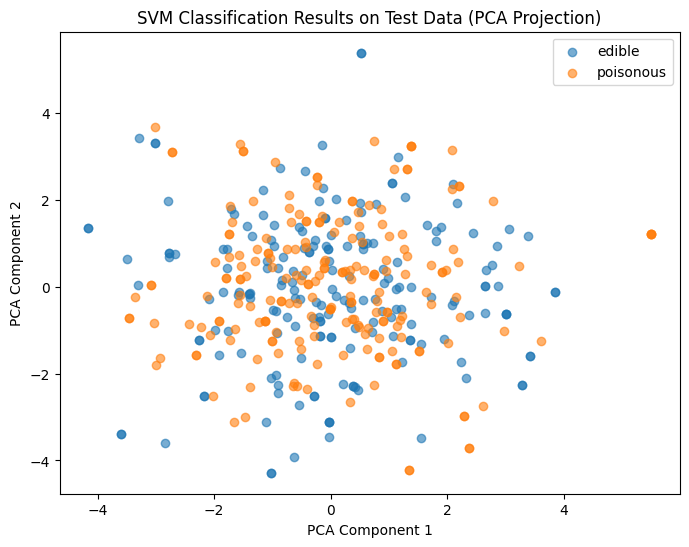

In [54]:
plt.figure(figsize=(8,6))

for label in np.unique(y_pred_base):
    plt.scatter(
        X_test_pca[y_pred_base == label, 0],
        X_test_pca[y_pred_base == label, 1],
        label=label,
        alpha=0.6
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("SVM Classification Results on Test Data (PCA Projection)")
plt.legend()
plt.show()


Since the mushroom dataset contains high-dimensional features after one-hot encoding, direct visualization of the SVM decision boundary is not feasible. Therefore, PCA was applied to project the test data into two dimensions solely for visualization purposes. The plot illustrates how the SVM classifier separates edible and poisonous mushrooms in the reduced feature space. the visualization also emphasizes the need for hyperparameter tuning.

# Hyperparameter tuning

# 1.RBF-SVM

In [55]:
svm_rbf = SVC(kernel='rbf',
             class_weight='balanced',
             random_state=42)
svm_rbf.fit(X_train_scaled,y_train)

SVC(class_weight='balanced', random_state=42)

In [57]:
y_pred_rbf = svm_rbf.predict(X_test_scaled)

In [59]:
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rbf))

Accuracy: 0.8375

Confusion Matrix:
 [[ 76  44]
 [ 21 259]]

Classification Report:
               precision    recall  f1-score   support

      edible       0.78      0.63      0.70       120
   poisonous       0.85      0.93      0.89       280

    accuracy                           0.84       400
   macro avg       0.82      0.78      0.79       400
weighted avg       0.83      0.84      0.83       400



The linear SVM model showed poor performance, particularly in identifying poisonous mushrooms, with a high number of false negatives. After switching to an RBF kernel, the model performance improved significantly. The RBF SVM achieved an accuracy of 83.75% and substantially reduced false negatives from 116 to 21. This indicates that the mushroom dataset exhibits non-linear decision boundaries, which are better captured by the RBF kernel. The improved recall for the poisonous class makes the RBF SVM more suitable for this safety-critical classification task.

# 2. Polynomial SVM

In [61]:
svm_poly = SVC(
    kernel='poly',
    degree=3,
    class_weight='balanced',
    random_state=42
)

svm_poly.fit(X_train_scaled, y_train)

y_pred_poly = svm_poly.predict(X_test_scaled)


In [62]:
print("Accuracy:", accuracy_score(y_test, y_pred_poly))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_poly))
print("\nClassification Report:\n", classification_report(y_test, y_pred_poly))

Accuracy: 0.8525

Confusion Matrix:
 [[ 64  56]
 [  3 277]]

Classification Report:
               precision    recall  f1-score   support

      edible       0.96      0.53      0.68       120
   poisonous       0.83      0.99      0.90       280

    accuracy                           0.85       400
   macro avg       0.89      0.76      0.79       400
weighted avg       0.87      0.85      0.84       400



# Comparison and Analysis

we tested the three svm kernels. Linear, RBF and polynomial, the linear kernel performed poorly indicating that the dataset is not linearly separable. the RBF kernel significantly better and balanced acheiving 83 percent accuracy by capturing non- linear relationships. the polynomial kernel achieved highest accuracy of 85 percent  and the highest recall for poisonous mushrooms 99% although it misclassified more edible mushrooms as poisonous.

Strengths of SVM for mushroom dataset:

        1. handles high-dimentional data after one hot encoding
        
        2. effective with non-linear decision boundaries(RDF and Polynomial)
        
        3.works well with moderate class imbalance using class weights
        
        4.strong performance for safety critical classification
        
Weaknesses:

        1. Requires carefull kernel selection and scaling
        
        2. difficult to interpret model decisions
        
        3. sensitive to hyperparameters
        

Real worl implications:
    SVM models can assist in food safety, agriculture, and mobile identification tools by helping classify mushrooms as edible or poisonous. In safety-critical applications, models like the polynomial SVM that minimize dangerous false negatives are particularly valuable.